In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# URLs dos dados
url1 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_1.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_4.csv"

# Leitura dos dados
loja1 = pd.read_csv(url1)
loja2 = pd.read_csv(url2)
loja3 = pd.read_csv(url3)
loja4 = pd.read_csv(url4)

# Adiciona identificação de loja
loja1["loja"] = "Loja 1"
loja2["loja"] = "Loja 2"
loja3["loja"] = "Loja 3"
loja4["loja"] = "Loja 4"

# Junta os dados
dados = pd.concat([loja1, loja2, loja3, loja4], ignore_index=True)

# Corrigir nomes de colunas: remover espaços e padronizar
dados.columns = dados.columns.str.strip().str.lower().str.replace(" ", "_")

# Verificar colunas padronizadas
print("Colunas disponíveis:", dados.columns.tolist())

# Adicionar coluna de faturamento (baseado no preço)
dados["faturamento"] = dados["preço"]

# Faturamento total por loja
faturamento = dados.groupby("loja")["faturamento"].sum().sort_values()
print("\nFaturamento total por loja:")
print(faturamento)

# Custo médio do frete por loja
frete_medio = dados.groupby("loja")["frete"].mean().sort_values()
print("\nCusto médio do frete por loja:")
print(frete_medio)

# Média de avaliação por loja
avaliacao_media = dados.groupby("loja")["avaliação_da_compra"].mean().sort_values()
print("\nMédia de avaliação dos clientes por loja:")
print(avaliacao_media)

# Categorias mais vendidas por loja
print("\nCategorias mais vendidas por loja:")
for loja in dados["loja"].unique():
    categorias = dados[dados["loja"] == loja]["categoria_do_produto"].value_counts().head()
    print(f"\n{loja}:")
    print(categorias)

# Produto mais vendido por loja
print("\nProdutos mais vendidos por loja:")
for loja in dados["loja"].unique():
    produto = dados[dados["loja"] == loja]["produto"].value_counts().idxmax()
    print(f"{loja}: {produto}")


Colunas disponíveis: ['produto', 'categoria_do_produto', 'preço', 'frete', 'data_da_compra', 'vendedor', 'local_da_compra', 'avaliação_da_compra', 'tipo_de_pagamento', 'quantidade_de_parcelas', 'lat', 'lon', 'loja']

Faturamento total por loja:
loja
Loja 4    1384497.58
Loja 3    1464025.03
Loja 2    1488459.06
Loja 1    1534509.12
Name: faturamento, dtype: float64

Custo médio do frete por loja:
loja
Loja 4    31.278997
Loja 3    33.074464
Loja 2    33.621941
Loja 1    34.691805
Name: frete, dtype: float64

Média de avaliação dos clientes por loja:
loja
Loja 1    3.976685
Loja 4    3.995759
Loja 2    4.037304
Loja 3    4.048326
Name: avaliação_da_compra, dtype: float64

Categorias mais vendidas por loja:

Loja 1:
categoria_do_produto
moveis              465
eletronicos         448
brinquedos          324
eletrodomesticos    312
esporte e lazer     284
Name: count, dtype: int64

Loja 2:
categoria_do_produto
moveis              442
eletronicos         422
brinquedos          313
eletrod

C:\Users\User\AppData\Local\Temp\ipykernel_6464\3844978709.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=faturamento.index, y=faturamento.values, palette="Greens")


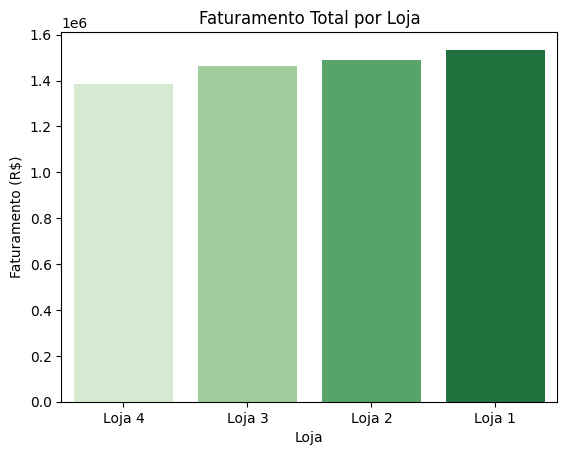

C:\Users\User\AppData\Local\Temp\ipykernel_6464\3844978709.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avaliacao_media.index, y=avaliacao_media.values, palette="Blues")


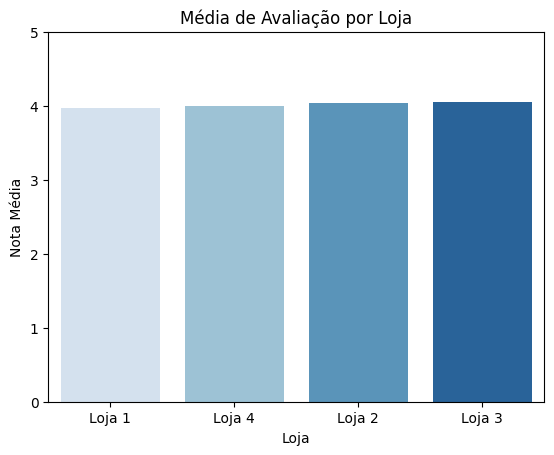

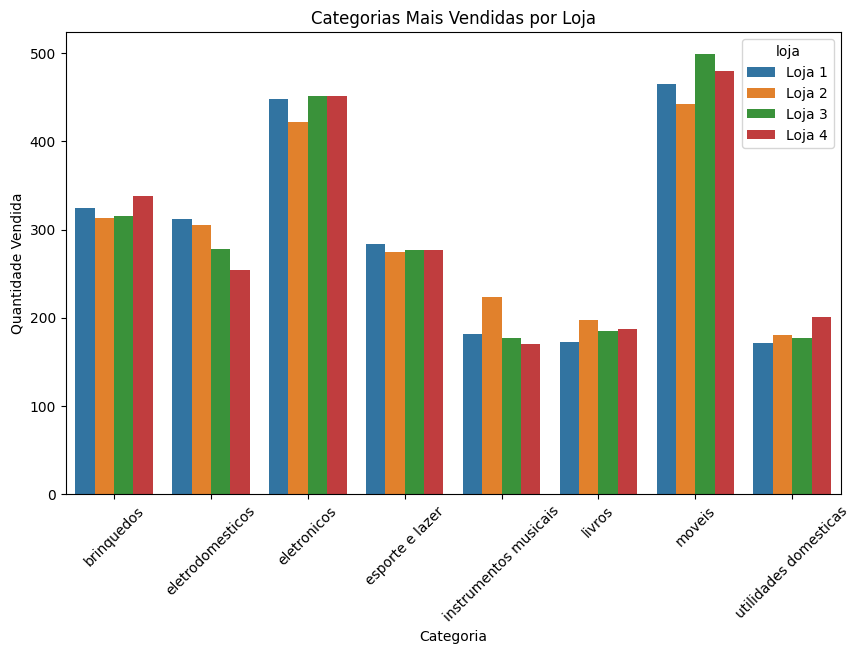

In [2]:
# Gráficos

# Gráfico 1: Faturamento total por loja
plt.figure()
sns.barplot(x=faturamento.index, y=faturamento.values, palette="Greens")
plt.title("Faturamento Total por Loja")
plt.ylabel("Faturamento (R$)")
plt.xlabel("Loja")
plt.show()

# Gráfico 2: Média de avaliação por loja
plt.figure()
sns.barplot(x=avaliacao_media.index, y=avaliacao_media.values, palette="Blues")
plt.title("Média de Avaliação por Loja")
plt.ylabel("Nota Média")
plt.xlabel("Loja")
plt.ylim(0, 5)
plt.show()

# Gráfico 3: Distribuição de Categorias por Loja
categorias_populares = dados.groupby(["loja", "categoria_do_produto"]).size().reset_index(name="quantidade")
plt.figure(figsize=(10, 6))
sns.barplot(x="categoria_do_produto", y="quantidade", hue="loja", data=categorias_populares)
plt.title("Categorias Mais Vendidas por Loja")
plt.ylabel("Quantidade Vendida")
plt.xlabel("Categoria")
plt.xticks(rotation=45)
plt.show()


In [3]:
# Ranking de desempenho

resultado = pd.DataFrame({
    "Faturamento Total": faturamento,
    "Frete Médio": frete_medio,
    "Avaliação Média": avaliacao_media
})

# Ranking: menor frete, maior avaliação, maior faturamento = melhor
resultado["Rank_Frete"] = resultado["Frete Médio"].rank()
resultado["Rank_Avaliacao"] = resultado["Avaliação Média"].rank(ascending=False)
resultado["Rank_Faturamento"] = resultado["Faturamento Total"].rank(ascending=False)

# Soma dos rankings
resultado["Ranking_Total"] = resultado[["Rank_Frete", "Rank_Avaliacao", "Rank_Faturamento"]].sum(axis=1)

# Ordena para ver a melhor loja
resultado = resultado.sort_values("Ranking_Total")
display(resultado)

# Recomendação final
loja_recomendada = resultado.index[0]
print(f"\nA loja melhor no ranking  é :  {loja_recomendada}")

,Faturamento Total,Frete Médio,Avaliação Média,Rank_Frete,Rank_Avaliacao,Rank_Faturamento,Ranking_Total
loja,,,,,,,
Loja 3,1464025.03,33.074464,4.048326,2.0,1.0,3.0,6.0
Loja 2,1488459.06,33.621941,4.037304,3.0,2.0,2.0,7.0
Loja 4,1384497.58,31.278997,3.995759,1.0,3.0,4.0,8.0
Loja 1,1534509.12,34.691805,3.976685,4.0,4.0,1.0,9.0



A loja melhor no ranking  é :  Loja 3
